# Setup

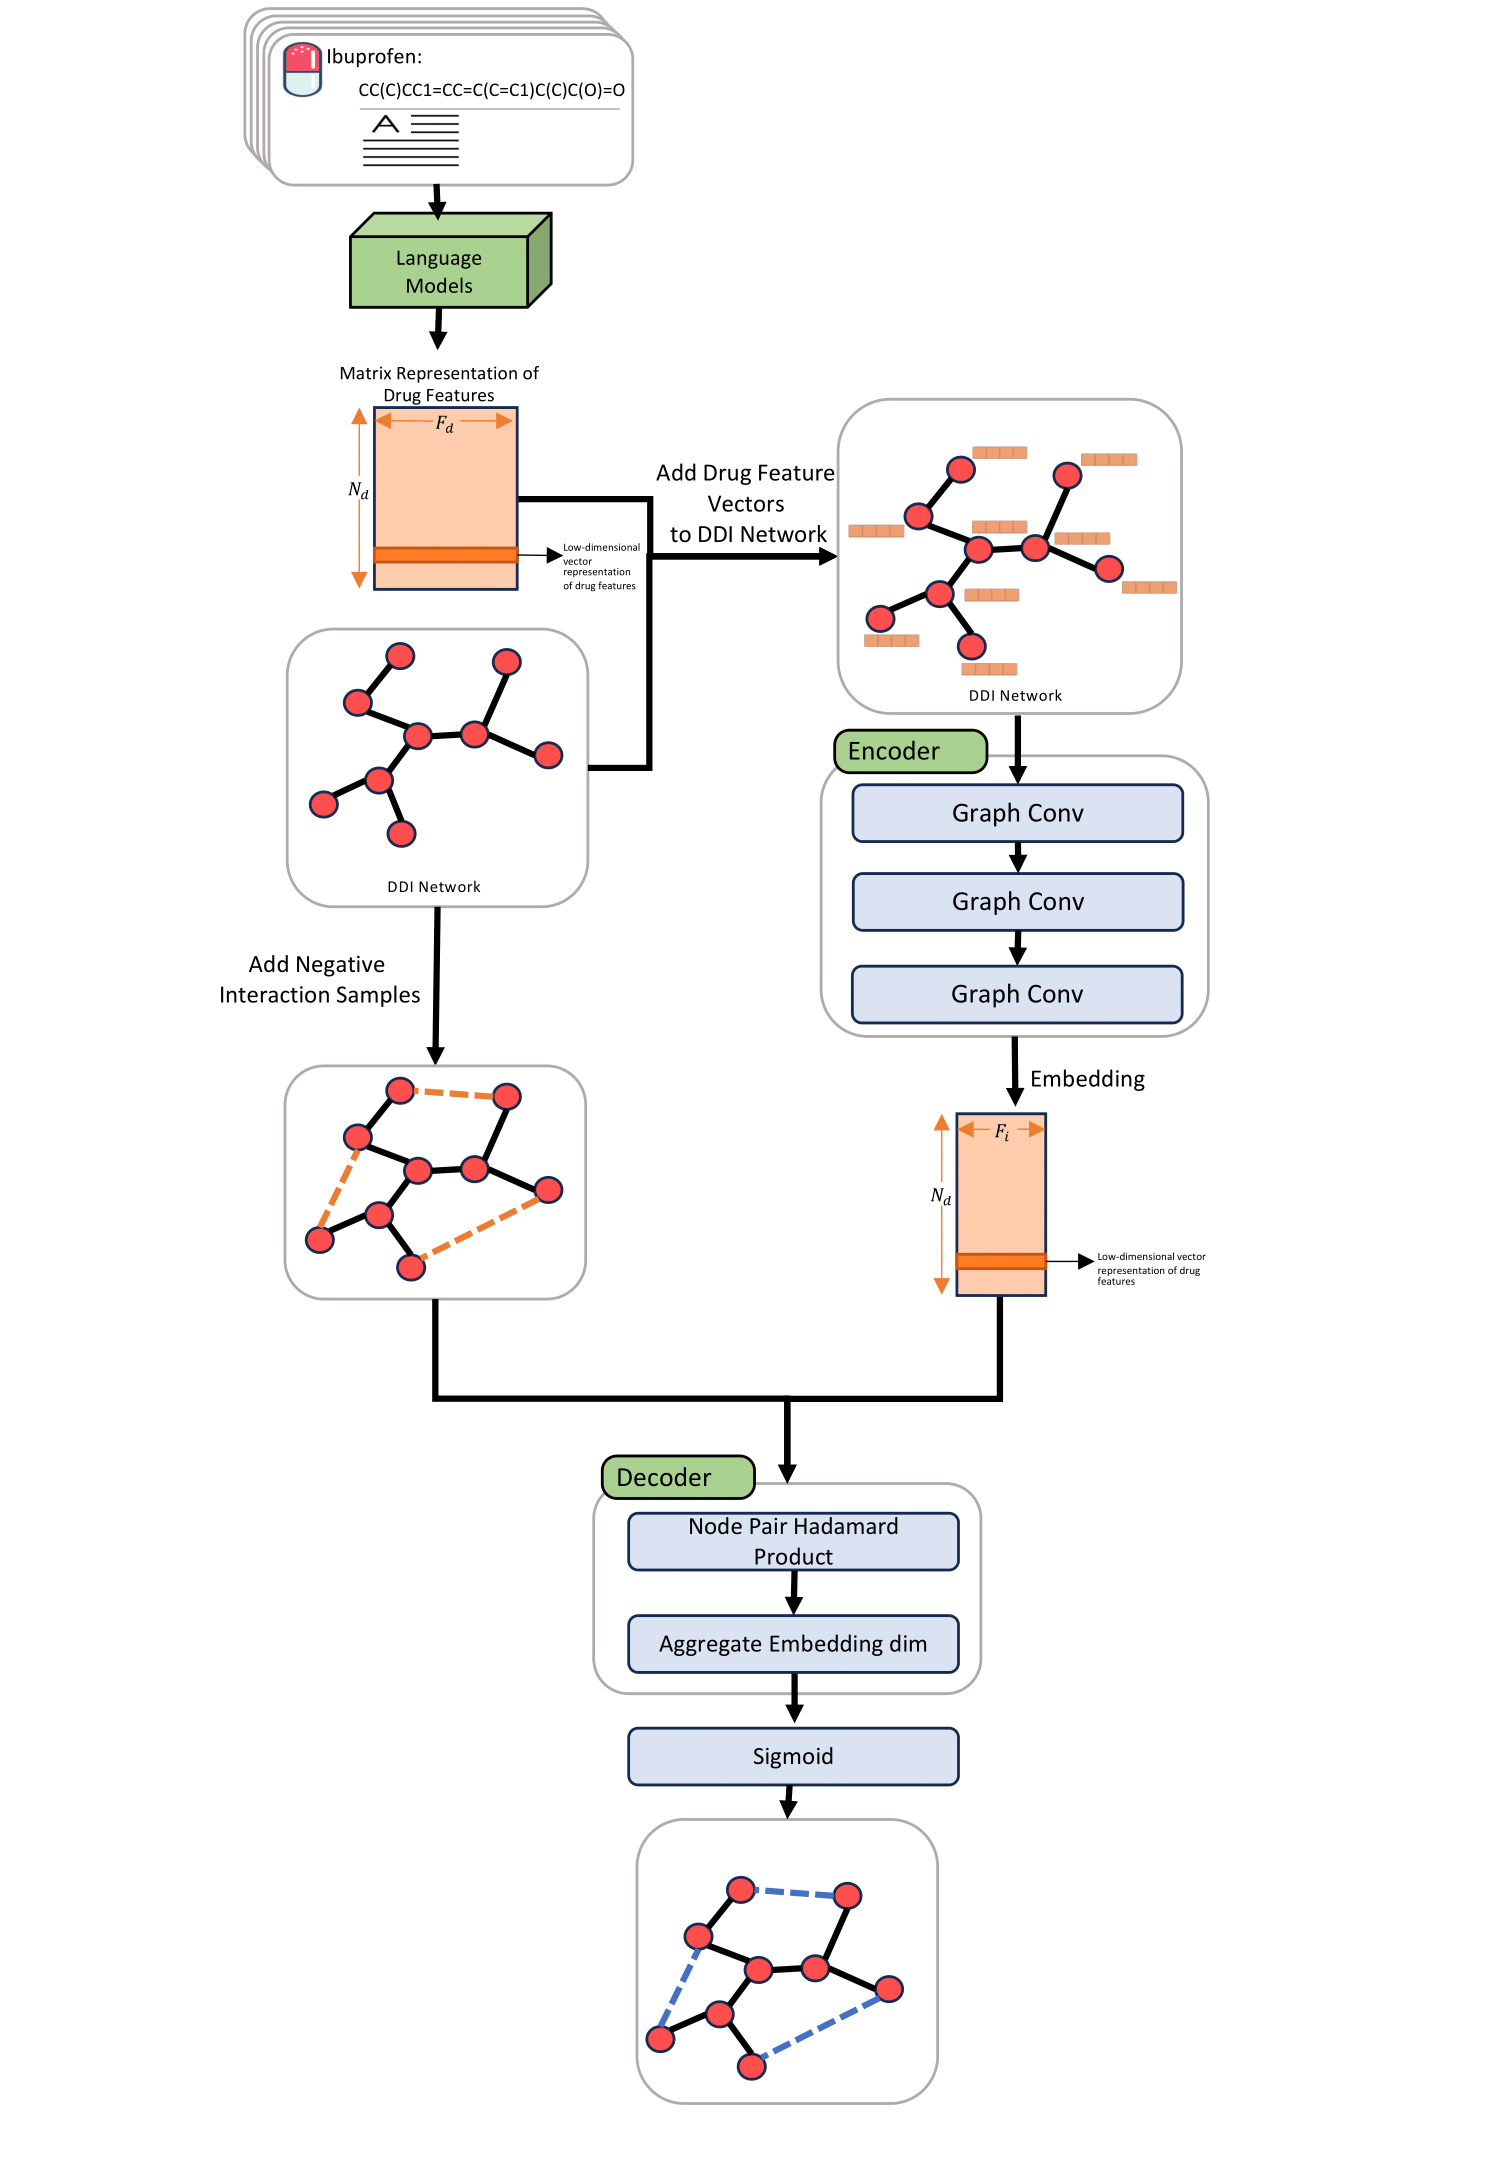

# Experiments

In [1]:
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from sklearn.manifold import TSNE
from sklearn.metrics import (
    PrecisionRecallDisplay,
    precision_recall_curve,
    confusion_matrix,
    f1_score,
    RocCurveDisplay,
    roc_curve,
)

import plotly.express as px

from ddi_graph_neural_network.train_model import main
from ddi_graph_neural_network.config import Config, LossType


warnings.simplefilter(action="ignore", category=FutureWarning)

## Experiments on Loss Functions and Labels

This section describes how negative examples are constructed for training and the loss configurations evaluated.

Negatives for training

- Sampled negatives: unlabeled pairs (non‑positive edges) are sampled uniformly and treated as negatives for training. This approach assumes most unobserved pairs are true negatives but admits the risk of including unlabelled positives among sampled negatives.

- Observed (validated) negatives: use only the validated negative labels provided in the CRESCENDDI dataset. This produces a smaller negative set; to correct for class imbalance we compensate by weighting the loss rather than inflating the negative sample count.

- Upsampled negatives: augment the observed negatives by sampling with replacement so that the number of negative training examples matches the number of positive examples. This yields a balanced training set but changes the effective data distribution seen during training.

Experimental design

We evaluate combinations of three orthogonal design choices:

1. Loss function: either (a) plain binary cross‑entropy on logits (BCEWithLogitsLoss) or (b) a weighted binary cross‑entropy that scales the positive class contribution by a scalar multiplier.

2. Negative handling: whether negatives are upsampled to balance the training set or the original observed negatives are used.

3. Training negative selection: whether the training set uses only sampled negatives (i.e., sampled from the unlabeled pool) or explicitly uses the validated negatives (controlled by `use_only_sampled_negatives_in_train`).

Weighted binary cross‑entropy

We implement a weighted BCE to compensate for label imbalance. Let $p=\sigma(z)$ be the model probability (sigmoid of the logit $z$), $y\in\{0,1\}$ the true label, and $N_{pos},N_{neg}$ the counts of positive and negative examples used for training. We define a positive‑class scaling factor

$$
\alpha_{pos} = \mathrm{pos\_loss\_multiplier}\;\frac{N_{neg}}{N_{pos}},
$$

and set the negative weight to $\alpha_{neg}=1$. The per‑example weighted binary cross‑entropy is

$$
\mathcal{L}(p,y) = -\alpha_{pos}\,y\,\log p - \alpha_{neg}\,(1-y)\,\log(1-p).
$$

In PyTorch this behaviour is achieved by providing a `pos_weight` parameter to `BCEWithLogitsLoss` (equal to $\alpha_{pos}$ above), which multiplies the loss contribution of positive examples.

Focal loss (note)

The binary focal loss modifies cross‑entropy with a focusing term and is defined as

$$
\mathrm{FL}(p_t) = -\alpha\,(1-p_t)^{\gamma}\,\log(p_t),
$$

where $p_t$ is the model probability for the true class, $\alpha$ balances classes, and $\gamma\ge 0$ focuses training on hard examples. When $\gamma=0$ the focal loss reduces to a (possibly weighted) cross‑entropy. In our hyperparameter search the best focal parameter collapsed to $\gamma\approx 0$, so focal loss provided no empirical advantage over the weighted BCE in this task.

Summary of empirical finding

Across the tested combinations, preserving the empirical negative prevalence (using observed negatives) while compensating for imbalance via loss weighting produced the best generalisation (ROC and PR). Upsampling negatives to force class balance did not improve, and in some cases reduced, validation performance. The optimized positive multiplier used in our experiments was approximately $0.5$ (reported in the results tables and figures), consistent with the weighting rule above.

The following cells run the selected configurations and collect ROC and PR curves, reporting means and standard deviations when repetitions are used.

In [2]:
logging.basicConfig(level=logging.DEBUG, format="%(asctime)s - %(levelname)s - %(message)s")
logging.getLogger().setLevel(logging.DEBUG)

config = Config()

config.training.seed = 42
config.graph.seed_graph_sampling = 42
config.graph.current_graph = "DrugBank_CRESCENDDI"
config.run.take_negative_samples = True
config.training.repetitions = 1

### Optimizing individual losses

In [3]:
settings = [
{
    "loss_type": LossType.BCEWithLogitsLoss,
    "pos_loss_multiplier": 1,
    "upsample_negative_labels": True,
    "use_only_sampled_negatives_in_train": False,
},
{
    "loss_type": LossType.BCEWithLogitsLoss,
    "pos_loss_multiplier": 1,
    "upsample_negative_labels": True,
    "use_only_sampled_negatives_in_train": True,
},
{
    "loss_type": LossType.WeightedBCEWithLogitsLoss,
    "pos_loss_multiplier": 0.5,
    "upsample_negative_labels": True,
    "use_only_sampled_negatives_in_train": False,
},
{
    "loss_type": LossType.WeightedBCEWithLogitsLoss,
    "pos_loss_multiplier": 0.5,
    "upsample_negative_labels": True,
    "use_only_sampled_negatives_in_train": True,
},
{
    "loss_type": LossType.WeightedBCEWithLogitsLoss,
    "pos_loss_multiplier": 0.5,
    "upsample_negative_labels": False,
    "use_only_sampled_negatives_in_train": False,
},
{
    "loss_type": LossType.WeightedBCEWithLogitsLoss,
    "pos_loss_multiplier": 0.5,
    "upsample_negative_labels": False,
    "use_only_sampled_negatives_in_train": True,
},
]


In [39]:
import pandas as pd

pd.set_option('display.float_format', lambda x: f'{x:.4f}')

train_setttings = [
    (2272, 27794),
    (0, 30066),
    (2272, 27794),
    (0, 30066),
    (2272, 0),
    (0, 2272)
]
n_pos_train = 30066
train_setttings_df = pd.DataFrame(train_setttings, columns=['Observed Negatives in Train', 'Sampled Negatives in Train'])
train_setttings_df['Observed Positives in Train'] = n_pos_train
train_setttings_df['Positive Loss Multiplier'] = [r['pos_loss_multiplier'] for r in settings]
train_setttings_df['Loss Function'] = [str(r['loss_type']).split('.')[-1] for r in settings]
train_setttings_df['Weight Factor Negative Loss'] = n_pos_train / ( (train_setttings_df['Observed Negatives in Train'] + train_setttings_df['Sampled Negatives in Train']) * train_setttings_df['Positive Loss Multiplier'])
train_setttings_df = train_setttings_df[['Loss Function', 'Observed Positives in Train', 'Observed Negatives in Train', 'Sampled Negatives in Train', 'Weight Factor Negative Loss']]
train_setttings_df.index = [f"S{i+1}" for i in range(len(train_setttings_df))]
train_setttings_df

# display as markdown
from IPython.display import Markdown, display
md = train_setttings_df.to_markdown()
display(Markdown("### Training Set Configurations\n\n" + md))


### Training Set Configurations

|    | Loss Function             |   Observed Positives in Train |   Observed Negatives in Train |   Sampled Negatives in Train |   Weight Factor Negative Loss |
|:---|:--------------------------|------------------------------:|------------------------------:|-----------------------------:|------------------------------:|
| S1 | BCEWithLogitsLoss         |                         30066 |                          2272 |                        27794 |                        1      |
| S2 | BCEWithLogitsLoss         |                         30066 |                             0 |                        30066 |                        1      |
| S3 | WeightedBCEWithLogitsLoss |                         30066 |                          2272 |                        27794 |                        2      |
| S4 | WeightedBCEWithLogitsLoss |                         30066 |                             0 |                        30066 |                        2      |
| S5 | WeightedBCEWithLogitsLoss |                         30066 |                          2272 |                            0 |                       26.4665 |
| S6 | WeightedBCEWithLogitsLoss |                         30066 |                             0 |                         2272 |                       26.4665 |

In [31]:
# Set how many repetitions to run for each configuration (adjust as desired)
repetitions = 3  # <- change this to increase/decrease runs per setting

results_list = []
for setting in settings:
    config.run.loss_type = setting["loss_type"]
    config.run.pos_loss_multiplier = setting["pos_loss_multiplier"]
    config.run.upsample_negative_labels = setting.get("upsample_negative_labels", False)
    config.run.use_only_sampled_negatives_in_train = setting.get("use_only_sampled_negatives_in_train", False)

    # apply repetitions to config so `main` will run multiple times and return mean/std metrics
    config.training.repetitions = repetitions

    name = f"{setting['loss_type'].name}|mult={setting['pos_loss_multiplier']}|ups={setting.get('upsample_negative_labels', False)}|only_sampled={setting.get('use_only_sampled_negatives_in_train', False)}|reps={repetitions}"
    print(f"=== Running: {name} ===")

    run = main(config)

    y_true = np.asarray(run["label"])  # shape (N,)
    y_scores = np.asarray(run["test_scores"])  # shape (N,)
    metrics = run["metrics"]

    # Extract mean/std from metrics (train `main` returns mean/std when repetitions>1)
    roc_mean = metrics.get("AUC_mean", metrics.get("AUC", None))
    roc_std = metrics.get("AUC_std", None)
    pr_mean = metrics.get("PR_AUC_mean", metrics.get("PR_AUC", None))
    pr_std = metrics.get("PR_AUC_std", None)

    precision, recall, pr_thresh = precision_recall_curve(y_true, y_scores)
    fpr, tpr, roc_thresh = roc_curve(y_true, y_scores)

    results_list.append(
        {
            "name": name,
            "setting": setting,
            "metrics": metrics,
            "ROC_AUC_mean": float(roc_mean) if roc_mean is not None else None,
            "ROC_AUC_std": float(roc_std) if roc_std is not None else None,
            "PR_AUC_mean": float(pr_mean) if pr_mean is not None else None,
            "PR_AUC_std": float(pr_std) if pr_std is not None else None,
            "precision": precision,
            "recall": recall,
            "pr_thresh": pr_thresh,
            "fpr": fpr,
            "tpr": tpr,
            "roc_thresh": roc_thresh,
            "y_true": y_true,
            "y_scores": y_scores,
        }
    )

# Expose results for downstream cells
settings_results = results_list


2026-04-12 10:58:46,009 - DEBUG - Loading CSV graph: DrugBank_CRESCENDDI


=== Running: BCEWithLogitsLoss|mult=1|ups=True|only_sampled=False|reps=3 ===


2026-04-12 10:58:48,774 - DEBUG - Graph and Embeddings Intersection Summary:
Number of drugs in graph: 1516, 
Number of embedding drugs in graph: 1516, 
Number of drugs dropped from graph (not in embeddings): 23, 
Number of embedding drugs not in graph: 7207
Kept percentage of embedding drugs not in graph: 0.0%, 

2026-04-12 10:58:48,985 - DEBUG - Final graph has 1516 nodes and 53892 edges.
Positive edges: 50108, 
Negative edges: 3784
2026-04-12 10:58:48,987 - DEBUG - Run 1/3 for DESC_GPT | LR: 0.0003


======== DESC_GPT ========


2026-04-12 10:58:49,416 - DEBUG - Sampling 27794 negative edges to add to training data.
2026-04-12 10:58:49,452 - DEBUG - After upsampling, training data has 30066 positive and 30066 negative samples.
2026-04-12 10:59:14,415 - DEBUG - Early stopping at epoch 64
2026-04-12 10:59:14,422 - DEBUG - Run 2/3 for DESC_GPT | LR: 0.0003
2026-04-12 10:59:14,625 - DEBUG - Sampling 27794 negative edges to add to training data.
2026-04-12 10:59:14,629 - DEBUG - After upsampling, training data has 30066 positive and 30066 negative samples.
2026-04-12 10:59:43,062 - DEBUG - Run 3/3 for DESC_GPT | LR: 0.0003
2026-04-12 10:59:43,278 - DEBUG - Sampling 27794 negative edges to add to training data.
2026-04-12 10:59:43,286 - DEBUG - After upsampling, training data has 30066 positive and 30066 negative samples.
2026-04-12 11:00:10,189 - DEBUG - Early stopping at epoch 91
2026-04-12 11:00:10,202 - DEBUG - Loading CSV graph: DrugBank_CRESCENDDI


...

-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE DESC_GPT -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.7760
PR_AUC: 0.9767
std ROC_AUC: 0.0060
std PR_AUC: 0.0006
repetitions: 3
-------------------------------
=== Running: WeightedBCEWithLogitsLoss|mult=0.5|ups=False|only_sampled=True|reps=3 ===


2026-04-12 11:02:57,329 - DEBUG - Graph and Embeddings Intersection Summary:
Number of drugs in graph: 1516, 
Number of embedding drugs in graph: 1516, 
Number of drugs dropped from graph (not in embeddings): 23, 
Number of embedding drugs not in graph: 7207
Kept percentage of embedding drugs not in graph: 0.0%, 

2026-04-12 11:02:57,398 - DEBUG - Final graph has 1516 nodes and 53892 edges.
Positive edges: 50108, 
Negative edges: 3784
2026-04-12 11:02:57,402 - DEBUG - Run 1/3 for DESC_GPT | LR: 0.0003
2026-04-12 11:02:57,419 - DEBUG - Dropped negative samples from training data. Training data now has 30066.0 positive samples and 0 negative samples.


======== DESC_GPT ========


2026-04-12 11:02:57,607 - DEBUG - Sampling 2272 negative edges to add to training data.
2026-04-12 11:02:57,611 - DEBUG - After upsampling, training data has 30066 positive and 2272 negative samples.
2026-04-12 11:02:57,621 - DEBUG - Using imbalanced loss with pos_weight: 0.0378
2026-04-12 11:03:04,686 - DEBUG - Early stopping at epoch 28
2026-04-12 11:03:04,693 - DEBUG - Run 2/3 for DESC_GPT | LR: 0.0003
2026-04-12 11:03:04,705 - DEBUG - Dropped negative samples from training data. Training data now has 30066.0 positive samples and 0 negative samples.
2026-04-12 11:03:04,892 - DEBUG - Sampling 2272 negative edges to add to training data.
2026-04-12 11:03:04,895 - DEBUG - After upsampling, training data has 30066 positive and 2272 negative samples.
2026-04-12 11:03:04,905 - DEBUG - Using imbalanced loss with pos_weight: 0.0378
2026-04-12 11:03:14,064 - DEBUG - Early stopping at epoch 32
2026-04-12 11:03:14,071 - DEBUG - Run 3/3 for DESC_GPT | LR: 0.0003
2026-04-12 11:03:14,087 - DEBUG 

-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE DESC_GPT -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.7380
PR_AUC: 0.9712
std ROC_AUC: 0.0072
std PR_AUC: 0.0012
repetitions: 3
-------------------------------


In [32]:
# Recreate concise short codes and display legend
from IPython.display import Markdown, display

short_codes = {}
descriptions = []
for i, r in enumerate(settings_results):
    code = f"S{i+1}"
    short_codes[r['name']] = code
    desc = f"{r['setting']['loss_type'].name}, pos_mult={r['setting']['pos_loss_multiplier']}, upsample={r['setting']['upsample_negative_labels']}"
    descriptions.append((code, r['name'], desc))

md = "| Code | Short Name | Details |\n|---|---:|---|\n"
for code, name, desc in descriptions:
    md += f"| **{code}** | `{name}` | {desc} |\n"

display(Markdown("### Settings Legend\n\n" + md))

# Expose mappings for plotting cells
settings_short_codes = short_codes
settings_short_desc = {code: desc for code, _, desc in descriptions}

print('Legend created. Use `settings_short_codes` and `settings_short_desc` in subsequent cells.')

### Settings Legend

| Code | Short Name | Details |
|---|---:|---|
| **S1** | `BCEWithLogitsLoss|mult=1|ups=True|only_sampled=False|reps=3` | BCEWithLogitsLoss, pos_mult=1, upsample=True |
| **S2** | `BCEWithLogitsLoss|mult=1|ups=True|only_sampled=True|reps=3` | BCEWithLogitsLoss, pos_mult=1, upsample=True |
| **S3** | `WeightedBCEWithLogitsLoss|mult=0.5|ups=True|only_sampled=False|reps=3` | WeightedBCEWithLogitsLoss, pos_mult=0.5, upsample=True |
| **S4** | `WeightedBCEWithLogitsLoss|mult=0.5|ups=True|only_sampled=True|reps=3` | WeightedBCEWithLogitsLoss, pos_mult=0.5, upsample=True |
| **S5** | `WeightedBCEWithLogitsLoss|mult=0.5|ups=False|only_sampled=False|reps=3` | WeightedBCEWithLogitsLoss, pos_mult=0.5, upsample=False |
| **S6** | `WeightedBCEWithLogitsLoss|mult=0.5|ups=False|only_sampled=True|reps=3` | WeightedBCEWithLogitsLoss, pos_mult=0.5, upsample=False |


Legend created. Use `settings_short_codes` and `settings_short_desc` in subsequent cells.


### Settings Legend

| Code | Description |
|---|---|
| **S1** | BCEWithLogitsLoss, pos_mult=1, upsample=True |
| **S2** | BCEWithLogitsLoss, pos_mult=1, upsample=True |
| **S3** | WeightedBCEWithLogitsLoss, pos_mult=0.5, upsample=True |
| **S4** | WeightedBCEWithLogitsLoss, pos_mult=0.5, upsample=True |
| **S5** | WeightedBCEWithLogitsLoss, pos_mult=0.5, upsample=False |
| **S6** | WeightedBCEWithLogitsLoss, pos_mult=0.5, upsample=False |


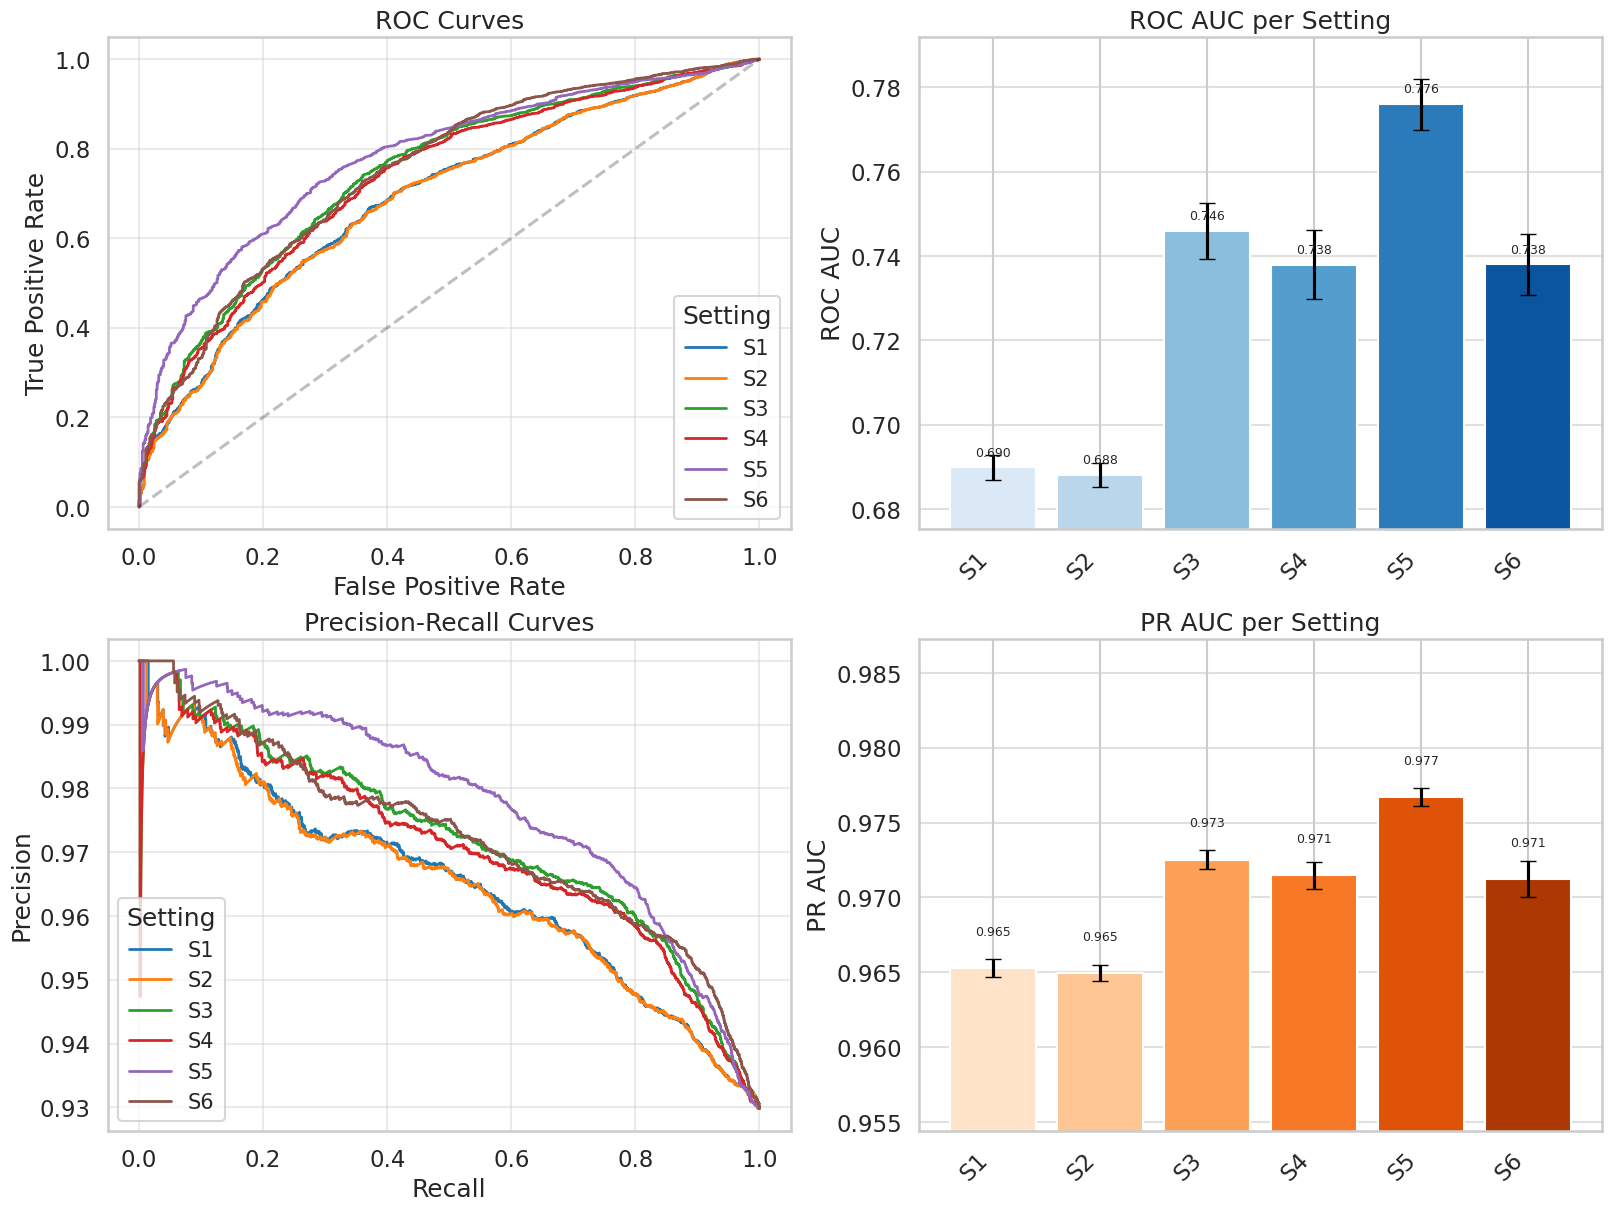

Saved combined report grid to: /home/giobbi/DDI_LLM_repo/DDI_with_ML/analysis/analysis_results_figs/report_grid.png
Saved summary CSV to: /home/giobbi/DDI_LLM_repo/DDI_with_ML/analysis/analysis_results_figs/settings_summary.csv


In [33]:
# Consolidated report: 2x2 grid (ROC curves | ROC AUC) / (PR curves | PR AUC)
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from IPython.display import Markdown, display

sns.set_style('whitegrid')
sns.set_context('talk')

# Build summary DataFrame
rows = []
for r in settings_results:
    rows.append(
        {
            "name": r["name"],
            "short": settings_short_codes.get(r["name"], r["name"]),
            "loss_type": r["setting"]["loss_type"].name,
            "pos_loss_multiplier": r["setting"]["pos_loss_multiplier"],
            "upsample_negative_labels": r["setting"]["upsample_negative_labels"],
            "ROC_AUC_mean": r.get("ROC_AUC_mean", np.nan),
            "ROC_AUC_std": r.get("ROC_AUC_std", 0) if r.get("ROC_AUC_std", None) is not None else 0,
            "PR_AUC_mean": r.get("PR_AUC_mean", np.nan),
            "PR_AUC_std": r.get("PR_AUC_std", 0) if r.get("PR_AUC_std", None) is not None else 0,
            "precision": r.get('precision'),
            "recall": r.get('recall'),
            "fpr": r.get('fpr'),
            "tpr": r.get('tpr'),
        }
    )

summary_df = pd.DataFrame(rows)
summary_df = summary_df.sort_values('short')

# Display concise legend
legend_md = "### Settings Legend\n\n" + "| Code | Description |\n|---|---|\n"
for code, desc in settings_short_desc.items():
    legend_md += f"| **{code}** | {desc} |\n"
display(Markdown(legend_md))

# Create figure directory
fig_dir = os.path.join(os.getcwd(), "analysis_results_figs")
os.makedirs(fig_dir, exist_ok=True)

labels = summary_df['short'].to_list()
indices = np.arange(len(labels))

# Helper to compute y limits with offset
def compute_ylim_with_offset(means, errs=None, min_range=0.03):
    means = np.asarray(means, dtype=float)
    errs = np.zeros_like(means) if errs is None else np.asarray(errs, dtype=float)
    valid = ~np.isnan(means)
    if not valid.any():
        return 0.0, 1.0
    min_val = np.nanmin(means[valid] - errs[valid])
    max_val = np.nanmax(means[valid] + errs[valid])
    data_range = max_val - min_val
    margin = max(0.01, 0.06 * data_range)
    lower = max(0.0, min_val - margin)
    upper = min(1.0, max_val + margin)
    if (upper - lower) < min_range:
        upper = min(1.0, lower + min_range)
        lower = max(0.0, upper - min_range)
    return lower, upper

# Prepare arrays for bars
roc_means = summary_df['ROC_AUC_mean'].to_numpy(dtype=float)
roc_err = summary_df['ROC_AUC_std'].to_numpy(dtype=float)
pr_means = summary_df['PR_AUC_mean'].to_numpy(dtype=float)
pr_err = summary_df['PR_AUC_std'].to_numpy(dtype=float)

roc_low, roc_hi = compute_ylim_with_offset(roc_means, roc_err)
pr_low, pr_hi = compute_ylim_with_offset(pr_means, pr_err)

# Create 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
(ax_roc_curve, ax_roc_bar), (ax_pr_curve, ax_pr_bar) = axes

# Top-left: ROC curves (no numeric values in legend)
for _, row in summary_df.iterrows():
    short = row['short']
    mask = [r for r in settings_results if settings_short_codes.get(r['name']) == short]
    if mask:
        r = mask[0]
        ax_roc_curve.plot(r['fpr'], r['tpr'], label=short, linewidth=2)
ax_roc_curve.plot([0,1],[0,1],'k--', alpha=0.25)
ax_roc_curve.set_title('ROC Curves')
ax_roc_curve.set_xlabel('False Positive Rate')
ax_roc_curve.set_ylabel('True Positive Rate')
ax_roc_curve.grid(alpha=0.4)
ax_roc_curve.legend(title='Setting', fontsize='small')

# Top-right: ROC AUC bar
bars_roc = ax_roc_bar.bar(indices, roc_means, yerr=roc_err, capsize=6, color=sns.color_palette('Blues', n_colors=len(labels)))
ax_roc_bar.set_xticks(indices)
ax_roc_bar.set_xticklabels(labels, rotation=45, ha='right')
ax_roc_bar.set_ylim(roc_low, roc_hi)
ax_roc_bar.set_title('ROC AUC per Setting')
ax_roc_bar.set_ylabel('ROC AUC')
ax_roc_bar.grid(axis='y', alpha=0.6)
for rect in bars_roc:
    h = rect.get_height()
    ax_roc_bar.text(rect.get_x() + rect.get_width()/2., h + 0.002, f"{h:.3f}", ha='center', va='bottom', fontsize=9)

# Bottom-left: Precision-Recall curves (no numeric values in legend)
for _, row in summary_df.iterrows():
    short = row['short']
    mask = [r for r in settings_results if settings_short_codes.get(r['name']) == short]
    if mask:
        r = mask[0]
        ax_pr_curve.plot(r['recall'], r['precision'], label=short, linewidth=2)
ax_pr_curve.set_title('Precision-Recall Curves')
ax_pr_curve.set_xlabel('Recall')
ax_pr_curve.set_ylabel('Precision')
ax_pr_curve.grid(alpha=0.4)
ax_pr_curve.legend(title='Setting', fontsize='small', loc='lower left')

# Bottom-right: PR AUC bar
bars_pr = ax_pr_bar.bar(indices, pr_means, yerr=pr_err, capsize=6, color=sns.color_palette('Oranges', n_colors=len(labels)))
ax_pr_bar.set_xticks(indices)
ax_pr_bar.set_xticklabels(labels, rotation=45, ha='right')
ax_pr_bar.set_ylim(pr_low, pr_hi)
ax_pr_bar.set_title('PR AUC per Setting')
ax_pr_bar.set_ylabel('PR AUC')
ax_pr_bar.grid(axis='y', alpha=0.6)
for rect in bars_pr:
    h = rect.get_height()
    ax_pr_bar.text(rect.get_x() + rect.get_width()/2., h + 0.002, f"{h:.3f}", ha='center', va='bottom', fontsize=9)

# Save combined report figure
report_path = os.path.join(fig_dir, 'report_grid.png')
fig.savefig(report_path, dpi=180)
plt.show()
print(f"Saved combined report grid to: {report_path}")

# Also save summary CSV
summary_csv = os.path.join(fig_dir, 'settings_summary.csv')
summary_df.to_csv(summary_csv, index=False)
print(f"Saved summary CSV to: {summary_csv}")

Outcome:

- Switchting from BCE to Weighted improves performance with a near optimal factor of pos_loss_multiplier = 0.5

- using the true observed negative labels as learning signal improves performance to the pendent where this nubmer is sampled.
- The setting where only the true observed negatives are used and the class imbalance is tackled via the weighted loss function performs clearly the best. this indicates that the true negatives indeed deliver a stronger learning signal.


In [34]:
results_df = pd.DataFrame(settings_results)[['name', 'ROC_AUC_mean', 'ROC_AUC_std', 'PR_AUC_mean', 'PR_AUC_std']]
# set index to short code
results_df['Run Setting'] = results_df['name'].map(settings_short_codes)
results_df = results_df.set_index('Run Setting')
results_df = results_df[['ROC_AUC_mean', 'ROC_AUC_std', 'PR_AUC_mean', 'PR_AUC_std']]
# display as markdown
md = results_df.to_markdown()
display(Markdown("### Summary of Metrics\n\n" + md))


### Summary of Metrics

| Run Setting   |   ROC_AUC_mean |   ROC_AUC_std |   PR_AUC_mean |   PR_AUC_std |
|:--------------|---------------:|--------------:|--------------:|-------------:|
| S1            |       0.689876 |    0.00302541 |      0.965285 |  0.000593409 |
| S2            |       0.688061 |    0.002848   |      0.964948 |  0.000559368 |
| S3            |       0.74588  |    0.00662824 |      0.972528 |  0.000650776 |
| S4            |       0.737939 |    0.00820095 |      0.97149  |  0.000904658 |
| S5            |       0.776012 |    0.00600816 |      0.976694 |  0.000606388 |
| S6            |       0.738027 |    0.00716035 |      0.971238 |  0.00118858  |

# Experiment of Embeddings

In [50]:
logging.basicConfig(level=logging.DEBUG, format="%(asctime)s - %(levelname)s - %(message)s")
logging.getLogger().setLevel(logging.DEBUG)

config = Config()

config.training.seed = 42
config.graph.seed_graph_sampling = 42
config.graph.current_graph = "DrugBank_CRESCENDDI"
config.run.take_negative_samples = True
config.training.repetitions = 1
config.run.loss_type = LossType.WeightedBCEWithLogitsLoss
config.run.pos_loss_multiplier = 0.5
config.run.upsample_negative_labels = False
config.run.use_only_sampled_negatives_in_train = False
config.graph.feature = "DESC_GPT"

In [54]:
settings = [{
    "feature": "__ONES__",
},
{
    "feature": "DESC_GPT",
}]

In [55]:
for setting in settings:
    config.graph.feature = setting.get("feature")
    name = f"Feature: {config.graph.feature}"
    print(f"=== Running: {name} ===")

    run = main(config)

    y_true = np.asarray(run["label"])  # shape (N,)
    y_scores = np.asarray(run["test_scores"])  # shape (N,)
    metrics = run["metrics"]

    roc_mean = metrics.get("AUC_mean", metrics.get("AUC", None))
    roc_std = metrics.get("AUC_std", None)
    pr_mean = metrics.get("PR_AUC_mean", metrics.get("PR_AUC", None))
    pr_std = metrics.get("PR_AUC_std", None)

    precision, recall, pr_thresh = precision_recall_curve(y_true, y_scores)
    fpr, tpr, roc_thresh = roc_curve(y_true, y_scores)


2026-04-12 11:44:48,621 - DEBUG - Loading CSV graph: DrugBank_CRESCENDDI


Config(graph=GraphParams(current_graph='DrugBank_CRESCENDDI', feature='__ONES__', col_name_drug_id='Drug ID', seed_graph_sampling=42, available_graphs={'DrugBank': '/data/giobbi/GRAPH/drugbank_graph.csv', 'positive_edges_CRESCENDDI': '/data/giobbi/CRESCENDDI/positive_edges_CRESCENDDI.csv', 'CRESCENDDI': '/data/giobbi/CRESCENDDI/CRESCENDDI_wo_contradiction.csv', 'DrugBank_CRESCENDDI': '/data/giobbi/GRAPH/drugbank_crescenddi_graph_wo_contradiction.csv', 'ogbl-ddi': '/data/giobbi'}), training=TrainingParams(learning_rate=0.0003, epochs=100, patience=10, lr_lambda=0.96, repetitions=1, seed=42), run=RunSettings(take_negative_samples=True, balanced_labels=False, upsample_negative_labels=False, use_only_sampled_negatives_in_train=False, loss_type=<LossType.WeightedBCEWithLogitsLoss: 'WeightedBCEWithLogitsLoss'>, pos_loss_multiplier=0.5, focal_loss_gamma=2.0))
=== Running: Feature: __ONES__ ===


2026-04-12 11:44:48,828 - DEBUG - Final graph has 1539 nodes and 54892 edges.
Positive edges: 51108, 
Negative edges: 3784
2026-04-12 11:44:48,830 - DEBUG - Run 1/1 for __ONES__ | LR: 0.0003
2026-04-12 11:44:48,849 - DEBUG - Using imbalanced loss with pos_weight: 0.0370


======== __ONES__ ========


2026-04-12 11:44:53,072 - DEBUG - Early stopping at epoch 17
2026-04-12 11:44:53,085 - DEBUG - Loading CSV graph: DrugBank_CRESCENDDI


-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE __ONES__ -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.6597
PR_AUC: 0.9611
Config(graph=GraphParams(current_graph='DrugBank_CRESCENDDI', feature='DESC_GPT', col_name_drug_id='Drug ID', seed_graph_sampling=42, available_graphs={'DrugBank': '/data/giobbi/GRAPH/drugbank_graph.csv', 'positive_edges_CRESCENDDI': '/data/giobbi/CRESCENDDI/positive_edges_CRESCENDDI.csv', 'CRESCENDDI': '/data/giobbi/CRESCENDDI/CRESCENDDI_wo_contradiction.csv', 'DrugBank_CRESCENDDI': '/data/giobbi/GRAPH/drugbank_crescenddi_graph_wo_contradiction.csv', 'ogbl-ddi': '/data/giobbi'}), training=TrainingParams(learning_rate=0.0003, epochs=100, patience=10, lr_lambda=0.96, repetitions=1, seed=42), run=RunSettings(take_negative_samples=True, balanced_labels=False, upsample_negative_labels=False, use_only_sampled_negatives_in_train=False, loss_type=<LossType.WeightedBCEWithLogitsLoss: 'WeightedBCEWithLogitsLoss'>, pos_loss_multipli

2026-04-12 11:44:55,713 - DEBUG - Graph and Embeddings Intersection Summary:
Number of drugs in graph: 1516, 
Number of embedding drugs in graph: 1516, 
Number of drugs dropped from graph (not in embeddings): 23, 
Number of embedding drugs not in graph: 7207
Kept percentage of embedding drugs not in graph: 0.0%, 

2026-04-12 11:44:55,778 - DEBUG - Final graph has 1516 nodes and 53892 edges.
Positive edges: 50108, 
Negative edges: 3784
2026-04-12 11:44:55,780 - DEBUG - Run 1/1 for DESC_GPT | LR: 0.0003
2026-04-12 11:44:55,802 - DEBUG - Using imbalanced loss with pos_weight: 0.0378


======== DESC_GPT ========


2026-04-12 11:45:02,222 - DEBUG - Early stopping at epoch 26


-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE DESC_GPT -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.7824
PR_AUC: 0.9764
